# Parse Training Readiness Notebook

In [ ]:
import pandas as pd
import numpy as np 
import json 
import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path

In [ ]:
base_path = Path.cwd() / "data_raw/athlete_001/DI_CONNECT/DI-Connect-Metrics"

paths = [
    base_path / 'TrainingReadinessDTO_20240712_20241020_48001360.json',
    base_path / 'TrainingReadinessDTO_20241020_20250128_48001360.json',
    base_path / 'TrainingReadinessDTO_20250128_20250508_48001360.json',
    base_path / 'TrainingReadinessDTO_20250816_20251124_48001360.json',
    base_path / 'TrainingReadinessDTO_20251124_20260304_48001360.json',
    base_path / 'TrainingReadinessDTO_20260304_20260612_48001360.json'
]

training_readiness_df = pd.DataFrame()

for path in paths:
    with open(path, 'r') as f:
        data = json.load(f)
        df = pd.DataFrame(data)
        training_readiness_df = pd.concat([training_readiness_df, df], ignore_index=True)

print(training_readiness_df.head())
print(training_readiness_df.shape)

   userProfilePK calendarDate              timestamp    deviceId level  \
0       48001360   2024-07-16  2024-07-17T02:57:10.0  3476423097  NONE   
1       48001360   2024-07-17  2024-07-17T12:04:05.0  3476423097  NONE   
2       48001360   2024-07-18  2024-07-18T14:26:00.0  3476423097  NONE   
3       48001360   2024-07-19  2024-07-19T12:06:08.0  3476423097  NONE   
4       48001360   2024-07-20  2024-07-20T13:00:11.0  3476423097   LOW   

                feedbackLong       feedbackShort  sleepScoreFactorPercent  \
0                    UNKNOWN             UNKNOWN                        0   
1                    UNKNOWN             UNKNOWN                        0   
2                    UNKNOWN             UNKNOWN                        0   
3                    UNKNOWN             UNKNOWN                        0   
4  LOW_RT_MOD_OR_LOW_SS_POOR  FIND_TIME_TO_RELAX                       35   

  sleepScoreFactorFeedback  recoveryTime  ...  sleepHistoryFactorPercent  \
0               

In [3]:
print(training_readiness_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   userProfilePK                1233 non-null   int64  
 1   calendarDate                 1233 non-null   object 
 2   timestamp                    1233 non-null   object 
 3   deviceId                     1233 non-null   int64  
 4   level                        1233 non-null   object 
 5   feedbackLong                 1233 non-null   object 
 6   feedbackShort                1233 non-null   object 
 7   sleepScoreFactorPercent      1233 non-null   int64  
 8   sleepScoreFactorFeedback     1233 non-null   object 
 9   recoveryTime                 1233 non-null   int64  
 10  recoveryTimeFactorPercent    1233 non-null   int64  
 11  recoveryTimeFactorFeedback   1233 non-null   object 
 12  acwrFactorPercent            1233 non-null   int64  
 13  acwrFactorFeedback

In [4]:
cols_to_drop = [
    'userProfilePK', 'deviceId'
]

training_readiness_df.drop(columns=cols_to_drop, inplace=True)

In [5]:
# Check for repeated dates
print(training_readiness_df['calendarDate'].duplicated().sum())

# Check for missing values
print(training_readiness_df.isnull().sum())


670
calendarDate                     0
timestamp                        0
level                            0
feedbackLong                     0
feedbackShort                    0
sleepScoreFactorPercent          0
sleepScoreFactorFeedback         0
recoveryTime                     0
recoveryTimeFactorPercent        0
recoveryTimeFactorFeedback       0
acwrFactorPercent                0
acwrFactorFeedback               0
stressHistoryFactorPercent       0
stressHistoryFactorFeedback      0
hrvFactorPercent                 0
hrvFactorFeedback                0
sleepHistoryFactorPercent        0
sleepHistoryFactorFeedback       0
validSleep                       0
timestampLocal                   0
acuteLoad                        0
sleepScore                     597
recoveryTimeChangePhrase       607
score                            4
hrvWeeklyAverage                 5
inputContext                   148
dtype: int64


In [9]:
# Investigate repeated dates in more detail
training_readiness_df.groupby("calendarDate").size().sort_values(ascending=False).head(20)

example_day = (
    training_readiness_df["calendarDate"]
    .value_counts()
    .idxmax()
)

training_readiness_df[
    training_readiness_df["calendarDate"] == example_day
].sort_values("timestamp")

,calendarDate,timestamp,level,feedbackLong,feedbackShort,sleepScoreFactorPercent,sleepScoreFactorFeedback,recoveryTime,recoveryTimeFactorPercent,recoveryTimeFactorFeedback,...,sleepHistoryFactorPercent,sleepHistoryFactorFeedback,validSleep,timestampLocal,acuteLoad,sleepScore,recoveryTimeChangePhrase,score,hrvWeeklyAverage,inputContext
292,2025-01-28,2025-01-28T06:36:47.0,HIGH,HIGH_RT_AVAILABLE_SS_UNKNOWN_ACWR_POS,WELL_RECOVERED,0,NONE,1082,71,GOOD,...,0,NONE,False,2025-01-28T01:36:47.0,397,NaN,NaN,75.0,511.0,UPDATE_REALTIME_VARIABLES
296,2025-01-28,2025-01-28T06:36:47.0,HIGH,HIGH_RT_AVAILABLE_SS_UNKNOWN_ACWR_POS,WELL_RECOVERED,0,NONE,1082,71,GOOD,...,0,NONE,False,2025-01-28T01:36:47.0,397,NaN,NaN,75.0,511.0,UPDATE_REALTIME_VARIABLES
293,2025-01-28,2025-01-28T12:07:47.0,HIGH,HIGH_RT_AVAILABLE_SS_UNKNOWN_ACWR_POS,WELL_RECOVERED,0,NONE,751,80,GOOD,...,0,NONE,False,2025-01-28T07:07:47.0,325,NaN,NaN,79.0,511.0,AFTER_WAKEUP_RESET
297,2025-01-28,2025-01-28T12:07:47.0,HIGH,HIGH_RT_AVAILABLE_SS_UNKNOWN_ACWR_POS,WELL_RECOVERED,0,NONE,751,80,GOOD,...,0,NONE,False,2025-01-28T07:07:47.0,325,NaN,NaN,79.0,511.0,AFTER_WAKEUP_RESET
294,2025-01-28,2025-01-28T22:29:34.0,MODERATE,MOD_RT_MOD_OR_LOW_SS_UNKNOWN_ACWR_POS,BOOSTED_BY_LIGHTER_TRAINING,0,NONE,1135,70,GOOD,...,0,NONE,False,2025-01-28T17:29:34.0,405,NaN,NO_CHANGE_SLEEP,73.0,511.0,AFTER_POST_EXERCISE_RESET
298,2025-01-28,2025-01-28T22:29:34.0,MODERATE,MOD_RT_MOD_OR_LOW_SS_UNKNOWN_ACWR_POS,BOOSTED_BY_LIGHTER_TRAINING,0,NONE,1135,70,GOOD,...,0,NONE,False,2025-01-28T17:29:34.0,405,NaN,NO_CHANGE_SLEEP,73.0,511.0,AFTER_POST_EXERCISE_RESET
295,2025-01-28,2025-01-29T00:36:47.0,HIGH,HIGH_RT_AVAILABLE_SS_UNKNOWN_ACWR_POS,WELL_RECOVERED,0,NONE,978,74,GOOD,...,0,NONE,False,2025-01-28T19:36:47.0,405,NaN,NaN,75.0,511.0,UPDATE_REALTIME_VARIABLES
299,2025-01-28,2025-01-29T00:36:47.0,HIGH,HIGH_RT_AVAILABLE_SS_UNKNOWN_ACWR_POS,WELL_RECOVERED,0,NONE,978,74,GOOD,...,0,NONE,False,2025-01-28T19:36:47.0,405,NaN,NaN,75.0,511.0,UPDATE_REALTIME_VARIABLES


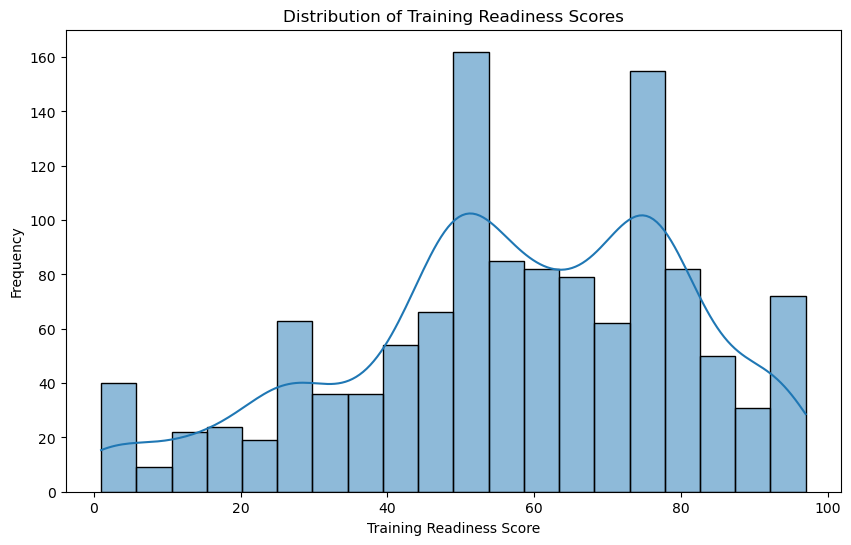

In [11]:
# Distribution of training readiness scores
plt.figure(figsize=(10, 6))
sns.histplot(training_readiness_df['score'], bins=20, kde=True)
plt.title('Distribution of Training Readiness Scores')
plt.xlabel('Training Readiness Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Save the cleaned data set to parquet for future use
output_path = Path.cwd() / 'data_processed/training_readiness_v1.parquet'
training_readiness_df.to_parquet(output_path, index=False)